<a href="https://colab.research.google.com/github/lab-ia-shared/Cardio-IA-4/blob/main/notebooks/cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive

Montando o Pipeline de Dados...
Found 4438 files belonging to 2 classes.
Using 3551 files for training.
Found 4438 files belonging to 2 classes.
Using 887 files for validation.
Found 1114 files belonging to 2 classes.

Pipeline de Dados criado com sucesso!


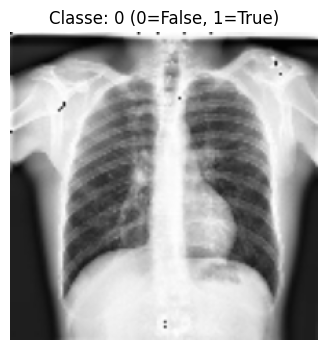

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive

# 1. Conecta o Google Drive ao Colab
drive.mount('/content/drive')

# Caminhos para as pastas
DATASET_PATH = "/content/drive/MyDrive/CardioIA_Datasets/dados_visuais/Cardiomegaly Disease Prediction Using CNN"
TRAIN_DIR = f"{DATASET_PATH}/train"
TEST_DIR = f"{DATASET_PATH}/test"

IMG_SIZE = (224, 224) # Redimensionamento Padrão
BATCH_SIZE = 32

print("\nMontando o Pipeline de Dados...")

# 2. Conjunto de Treino (Pegando 80% da pasta 'train')
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2, # Separa 20% para validação
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# 3. Conjunto de Validação (Os outros 20% para o modelo testar durante o treino)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# 4. Conjunto de Teste (Para a avaliação final)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

# 5. Normalização dos Pixels (Escala 0 a 1)
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))

# Otimização de performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

print("\nPipeline de Dados criado com sucesso!")

# Exibir uma imagem para validação visual
for images, labels in train_dataset.take(1):
    plt.figure(figsize=(4, 4))
    plt.imshow(images[0].numpy())
    plt.title(f"Classe: {int(labels[0])} (0=False, 1=True)")
    plt.axis("off")
    plt.show()
    break

In [ ]:
# Criando a arquitetura da CNN do Zero
model_do_zero = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Evita overfitting
    layers.Dense(1, activation='sigmoid') # 1 neurônio + Sigmoid = Classificação Binária
])

# Compilando o modelo
model_do_zero.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

print("Iniciando o treinamento da CNN do Zero...")
# Treinando
history_zero = model_do_zero.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset
)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iniciando o treinamento da CNN do Zero...
Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 1350s 12s/step - accuracy: 0.5432 - loss: 0.7192 - val_accuracy: 0.6629 - val_loss: 0.6547
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 15s 139ms/step - accuracy: 0.6229 - loss: 0.6492 - val_accuracy: 0.6505 - val_loss: 0.6131
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 22s 156ms/step - accuracy: 0.6553 - loss: 0.6207 - val_accuracy: 0.6956 - val_loss: 0.6039
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 16s 141ms/step - accuracy: 0.6812 - loss: 0.5977 - val_accuracy: 0.6370 - val_loss: 0.6016
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 16s 140ms/step - accuracy: 0.6981 - loss: 0.5712 - val_accuracy: 0.7046 - val_loss: 0.5655
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 15s 137ms/step - accuracy: 0.7198 - loss: 0.5525 - val_accuracy: 0.7091 - val_loss: 0.5712
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 15s 137ms/step - accuracy: 0.7364 - loss: 0.5236 - val_accuracy: 0.7080 - val_loss: 0.5765
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 1

In [ ]:
from tensorflow.keras.applications import VGG16

# Importando a VGG16 sem a camada de classificação final
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Congela os pesos da rede famosa

# Construindo o modelo final
model_tl = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid') # Saída binária combinando com o pipeline
])

model_tl.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

print("Iniciando o treinamento com Transfer Learning (VGG16)...")
history_tl = model_tl.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset
)



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Iniciando o treinamento com Transfer Learning (VGG16)...
Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 61s 418ms/step - accuracy: 0.6069 - loss: 0.9056 - val_accuracy: 0.6990 - val_loss: 0.5784
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 24s 212ms/step - accuracy: 0.6835 - loss: 0.5878 - val_accuracy: 0.7170 - val_loss: 0.5607
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 24s 218ms/step - accuracy: 0.6863 - loss: 0.5743 - val_accuracy: 0.7396 - val_loss: 0.5495
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 25s 224ms/step - accuracy: 0.7128 - loss: 0.5563 - val_accuracy: 0.7272 - val_loss: 0.5120
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 26s 229ms/step - accuracy: 0.6947 - loss: 0.5540 - val_accuracy: 0.7610 - val_loss: 0.5225
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 26s 230ms/step - accuracy: 0.7170 - loss: 0.5387 - val_accuracy: 0.6945 - val_loss: 0.5997
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 26s 229ms/step - accuracy: 0.6818 - loss: 0.5615 - val_accuracy: 0

Avaliando o modelo de Transfer Learning no dataset de teste...
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 479ms/step

--- Relatório de Classificação ---
                   precision    recall  f1-score   support

     Saudável (0)       0.73      0.77      0.75       557
Cardiomegalia (1)       0.76      0.71      0.73       557

         accuracy                           0.74      1114
        macro avg       0.74      0.74      0.74      1114
     weighted avg       0.74      0.74      0.74      1114



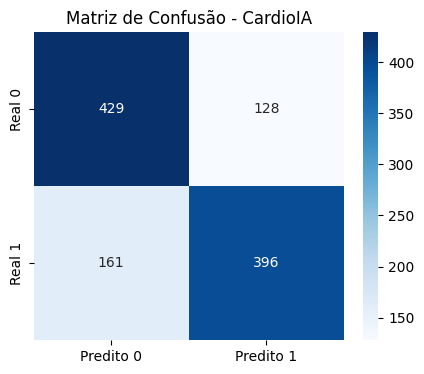

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("Avaliando o modelo de Transfer Learning no dataset de teste...")

# 1. Pegar as respostas reais do teste (gabarito)
y_true = np.concatenate([y for x, y in test_dataset], axis=0)

# 2. Fazer o modelo prever as imagens de teste
y_pred_probs = model_tl.predict(test_dataset)
# Como a saída é sigmoid (0 a 1), se for maior que 0.5 é classe 1 (True), senão é 0 (False)
y_pred = (y_pred_probs > 0.5).astype(int)

# 3. Imprimir Precision, Recall e F1-Score
print("\n--- Relatório de Classificação ---")
print(classification_report(y_true, y_pred, target_names=["Saudável (0)", "Cardiomegalia (1)"]))

# 4. Plotar a Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Predito 0", "Predito 1"],
            yticklabels=["Real 0", "Real 1"])
plt.title('Matriz de Confusão - CardioIA')
plt.show()

In [ ]:
# Salvando o arquivo final do modelo
model_tl.save('cardioia_vgg16_modelo.keras')
print("Modelo salvo com sucesso! Baixe o arquivo 'cardioia_vgg16_modelo.keras' no painel esquerdo do Colab.")

Modelo salvo com sucesso! Baixe o arquivo 'cardioia_vgg16_modelo.keras' no painel esquerdo do Colab.


In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image
import io

# 1. Criando os componentes visuais da interface
botao_upload = widgets.FileUpload(
    accept='.png,.jpg,.jpeg', # Aceita apenas formatos de imagem
    multiple=False            # Apenas uma imagem por vez
)

output_visual = widgets.Output()

print("--- ASSISTENTE CARDIOLÓGICO VIRTUAL: CARDIOIA ---")
print("Clique no botão abaixo para carregar um exame de Raio-X (.jpg ou .png):")
display(botao_upload, output_visual)

# 2. Função universal que processa a imagem e faz o diagnóstico
def analisar_imagem(change):
    with output_visual:
        clear_output() # Limpa a tela para a nova análise

        # Verifica se algum arquivo foi carregado
        if not botao_upload.value:
            return

        print("Processando exame... Por favor, aguarde.")

        if isinstance(botao_upload.value, dict):
            # Se for dicionário (versões anteriores), pega o primeiro valor
            arquivo_info = list(botao_upload.value.values())[0]
        else:
            # Se for lista/tupla (versões mais novas), pega o índice 0
            arquivo_info = botao_upload.value[0]

        conteudo_bytes = arquivo_info['content'] # Pega os bytes da imagem

        # Abre a imagem da memória usando BytesIO e garante que está em RGB
        img = Image.open(io.BytesIO(conteudo_bytes)).convert('RGB')

        # Exibe a imagem na tela para o usuário ver
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title("Exame Carregado")
        plt.show()

        # Pré-processamento padrão:
        img_redimensionada = img.resize((224, 224))
        img_array = np.array(img_redimensionada) / 255.0
        img_batch = np.expand_dims(img_array, axis=0) # Transforma em lote (batch size = 1)

        # 3. Executa a predição usando o modelo de Transfer Learning (VGG16)
        predicao_prob = model_tl.predict(img_batch)[0][0]

        print("\n--- RESULTADO DA ANÁLISE CLÍNICA ---")
        if predicao_prob > 0.5:
            porcentagem = predicao_prob * 100
            print(f"⚠️ DIAGNÓSTICO: ALERTA DE CARDIOMEGALIA DETECTADA")
            print(f"Confiabilidade do Modelo: {porcentagem:.2f}%")
        else:
            porcentagem = (1 - predicao_prob) * 100
            print(f"✅ DIAGNÓSTICO: EXAME DENTRO DOS PADRÕES DA NORMALIDADE")
            print(f"Confiabilidade do Modelo: {porcentagem:.2f}%")

# 4. Vincula o botão de upload à função de análise
botao_upload.observe(analisar_imagem, names='value')

--- ASSISTENTE CARDIOLÓGICO VIRTUAL: CARDIOIA ---
Clique no botão abaixo para carregar um exame de Raio-X (.jpg ou .png):


FileUpload(value={}, accept='.png,.jpg,.jpeg', description='Upload')

Output()